# 1. 📦 Imports & Setup

In [3]:
# Data manipulation
import pandas as pd

# Football data
from statsbombpy import sb

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# 2. 🔍 Explore Available Competitions

In [11]:
# Load all available competitions
competitions = sb.competitions()

# Filter La Liga (men's competitions only)
laliga = competitions[
    (competitions["competition_name"] == "La Liga") &
    (competitions["competition_gender"] == "male")
]

laliga[["competition_id", "season_id", "season_name"]]

,competition_id,season_id,season_name
38,11,90,2020/2021
39,11,42,2019/2020
40,11,4,2018/2019
41,11,1,2017/2018
42,11,2,2016/2017
43,11,27,2015/2016
44,11,26,2014/2015
45,11,25,2013/2014
46,11,24,2012/2013
47,11,23,2011/2012


# 3. ⚽ Load Matches

In [12]:
# Create list of (competition_id, season_id)
leagues = list(zip(laliga["competition_id"], laliga["season_id"]))

# Load matches across seasons
matches = pd.concat(
    [sb.matches(comp, season) for comp, season in leagues],
    ignore_index=True
)

print(f"Total matches: {len(matches)}")
matches.head()

Total matches: 868


,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3773386,2020-10-31,21:00:00.000,Spain - La Liga,2020/2021,Deportivo Alavés,Barcelona,1,1,available,available,2023-07-25T03:54:59.280826,2023-07-25T04:25:41.348202,8,Regular Season,Estadio de Mendizorroza,NaN,Pablo Javier Machín Díez,Ronald Koeman,1.1.0,2,2
1,3773565,2021-01-09,18:30:00.000,Spain - La Liga,2020/2021,Granada,Barcelona,0,4,available,available,2023-07-25T03:51:37.437064,2023-07-25T04:30:16.058384,18,Regular Season,Estadio Nuevo Los Cármenes,Ricardo De Burgos Bengoetxea,Diego Martínez Penas,Ronald Koeman,1.1.0,2,2
2,3773457,2021-05-16,18:30:00.000,Spain - La Liga,2020/2021,Barcelona,Celta Vigo,1,2,available,available,2022-12-02T09:26:39.496362,2023-04-27T23:03:53.506485,37,Regular Season,Spotify Camp Nou,NaN,Ronald Koeman,Eduardo Germán Coudet,1.1.0,2,2
3,3773631,2021-02-07,21:00:00.000,Spain - La Liga,2020/2021,Real Betis,Barcelona,2,3,available,available,2023-07-25T03:47:44.278651,2023-07-25T03:56:34.733180,22,Regular Season,Estadio Benito Villamarín,NaN,Manuel Luis Pellegrini Ripamonti,Ronald Koeman,1.1.0,2,2
4,3773665,2021-03-06,21:00:00.000,Spain - La Liga,2020/2021,Osasuna,Barcelona,0,2,available,available,2022-12-02T08:46:42.897589,2023-04-28T02:57:03.412841,26,Regular Season,Estadio El Sadar,Guillermo Cuadra Fernández,Jagoba Arrasate Elustondo,Ronald Koeman,1.1.0,2,2


# 4. 🎯 Select a Match & Load Lineups

In [13]:
# Example match
match_id = 3773386

# Inspect match info
matches[matches["match_id"] == match_id]

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3773386,2020-10-31,21:00:00.000,Spain - La Liga,2020/2021,Deportivo Alavés,Barcelona,1,1,available,available,2023-07-25T03:54:59.280826,2023-07-25T04:25:41.348202,8,Regular Season,Estadio de Mendizorroza,NaN,Pablo Javier Machín Díez,Ronald Koeman,1.1.0,2,2


In [14]:
# Load lineups for the match
lineups = sb.lineups(match_id=match_id)

# Select a team
team = "Barcelona"
lineup = lineups[team]

lineup.head()

,player_id,player_name,player_nickname,jersey_number,country,cards,positions
0,4447,Martin Braithwaite Christensen,Martin Braithwaite,9,Denmark,[],"[{'position_id': 21, 'position': 'Left Wing', ..."
1,5203,Sergio Busquets i Burgos,Sergio Busquets,5,Spain,"[{'time': '43:12', 'card_type': 'Yellow Card',...","[{'position_id': 9, 'position': 'Right Defensi..."
2,5211,Jordi Alba Ramos,Jordi Alba,18,Spain,[],"[{'position_id': 6, 'position': 'Left Back', '..."
3,5213,Gerard Piqué Bernabéu,Gerard Piqué,3,Spain,[],"[{'position_id': 3, 'position': 'Right Center ..."
4,5477,Ousmane Dembélé,None,11,France,[],"[{'position_id': 17, 'position': 'Right Wing',..."


# 5. 🧹 Extract the Starting XI (Core Logic)

In [15]:
def get_starting_xi(match_id: int, team: str) -> pd.DataFrame:
    """
    Extract the starting XI for a given team and match.
    """

    lineup = sb.lineups(match_id=match_id)[team].copy()

    # Expand positions
    df = lineup.explode("positions")
    pos = pd.json_normalize(df["positions"])

    df = pd.concat(
        [df.drop(columns="positions").reset_index(drop=True), pos],
        axis=1
    )

    # Filter starters
    starters = df[df["start_reason"] == "Starting XI"].copy()

    # Clean player names
    starters["player"] = (
        starters["player_nickname"]
        .fillna(starters["player_name"])
        .str.strip()
    )

    # Select relevant columns
    starters = starters[[
        "player",
        "jersey_number",
        "position"
    ]].sort_values("jersey_number")

    return starters.reset_index(drop=True)

In [16]:
starting_xi = get_starting_xi(match_id, team)
starting_xi

,player,jersey_number,position
0,Gerard Piqué,3,Right Center Back
1,Sergio Busquets,5,Right Defensive Midfield
2,Antoine Griezmann,7,Center Forward
3,Lionel Messi,10,Center Attacking Midfield
4,Ousmane Dembélé,11,Right Wing
5,Neto,13,Goalkeeper
6,Clément Lenglet,15,Left Center Back
7,Jordi Alba,18,Left Back
8,Sergi Roberto,20,Right Back
9,Frenkie de Jong,21,Left Defensive Midfield


# 9. 🧩 Simple Formation Detection

In [ ]:
import pandas as pd
from statsbombpy import sb

# --- Collect ALL positions + counts ---
position_counts = {}

for match_id in matches["match_id"]:
    try:
        lineups = sb.lineups(match_id=match_id)

        for team in lineups.keys():
            df = lineups[team]

            # Expand positions
            df_exp = df.explode("positions")
            pos = pd.json_normalize(df_exp["positions"])

            if "position" in pos.columns:
                for p in pos["position"].dropna():
                    position_counts[p] = position_counts.get(p, 0) + 1

    except Exception as e:
        # Skip problematic matches safely
        print(f"Skipped match {match_id}: {e}")

# --- Convert to DataFrame ---
positions_df = (
    pd.DataFrame(list(position_counts.items()), columns=["position", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

# --- Display results ---
print(f"Total unique positions: {positions_df['position'].nunique()}")
positions_df

In [117]:
def infer_formation(df: pd.DataFrame) -> str:
    """
    Improved formation inference with better midfield handling.
    """

    df = df[df["position"] != "Goalkeeper"].copy()
    df = df.drop_duplicates(subset="player")

    def classify(pos):
        pos = str(pos)

        # Defence
        if "Back" in pos:
            return "DEF"

        # Defensive midfield
        elif "Defensive Midfield" in pos:
            return "DM"

        # Attacking midfield
        elif "Attacking Midfield" in pos:
            return "AM"

        # Central midfield
        elif "Midfield" in pos:
            return "CM"

        # Attack
        elif any(x in pos for x in ["Wing", "Forward", "Striker"]):
            return "ATT"

        return "CM"  # safe fallback

    df["line"] = df["position"].apply(classify)

    defence = (df["line"] == "DEF").sum()
    dm = (df["line"] == "DM").sum()
    cm = (df["line"] == "CM").sum()
    am = (df["line"] == "AM").sum()
    attack = (df["line"] == "ATT").sum()

    # --- Smart grouping ---
    midfield = dm + cm + am

    return f"{defence}-{midfield}-{attack}"

In [118]:
formation = infer_formation(starting_xi)
print("Inferred formation:", formation)

Inferred formation: 4-3-3


In [134]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import pandas as pd

# --- Helper: clean short names properly ---
def get_short_name(name: str) -> str:
    parts = name.split()

    if len(parts) >= 2 and parts[-2].lower() in [
        "de", "da", "del", "van", "von", "dos", "di", "la", "le", "ter"
    ]:
        return " ".join(parts[-2:])
    
    return parts[-1]


# --- NEW: normalise positions (THIS FIXES YOUR BUG) ---
def normalise_position(pos: str) -> str:
    pos = str(pos)

    mapping = {
        "Right Wingback": "Right Wing Back",
        "Left Wingback": "Left Wing Back",
    }

    return mapping.get(pos, pos)


def plot_formation_comparison(match_id_1, match_id_2, team):

    # --- Load match info ---
    match1 = matches[matches["match_id"] == match_id_1].iloc[0]
    match2 = matches[matches["match_id"] == match_id_2].iloc[0]

    # --- Get data ---
    xi1 = get_starting_xi(match_id_1, team)
    xi2 = get_starting_xi(match_id_2, team)

    form1 = infer_formation(xi1)
    form2 = infer_formation(xi2)

    # --- Clean names ---
    xi1["short_name"] = xi1["player"].apply(get_short_name)
    xi2["short_name"] = xi2["player"].apply(get_short_name)

    # --- NORMALISE POSITIONS (CRITICAL) ---
    xi1["position"] = xi1["position"].apply(normalise_position)
    xi2["position"] = xi2["position"].apply(normalise_position)

    # --- Position map ---
    position_map = {
        "Goalkeeper": (5, 40),

        # Defence
        "Right Back": (20, 72),
        "Right Wing Back": (28, 75),
        "Right Center Back": (20, 56),
        "Center Back": (20, 40),
        "Left Center Back": (20, 24),
        "Left Back": (20, 8),
        "Left Wing Back": (28, 5),

        # Defensive midfield
        "Right Defensive Midfield": (42, 64),
        "Center Defensive Midfield": (42, 40),
        "Left Defensive Midfield": (42, 16),

        # Central midfield
        "Right Center Midfield": (58, 64),
        "Center Midfield": (58, 40),
        "Left Center Midfield": (58, 16),

        # Attacking midfield
        "Center Attacking Midfield": (72, 40),

        # Attack
        "Right Wing": (88, 72),
        "Left Wing": (88, 8),
        "Center Forward": (96, 40),
        "Striker": (96, 40)
    }

    position_order = {
        "Goalkeeper": 0,

        "Left Wing Back": 1,
        "Left Back": 2,
        "Left Center Back": 3,
        "Center Back": 4,
        "Right Center Back": 5,
        "Right Back": 6,
        "Right Wing Back": 7,

        "Left Defensive Midfield": 8,
        "Center Defensive Midfield": 9,
        "Right Defensive Midfield": 10,

        "Left Center Midfield": 11,
        "Center Midfield": 12,
        "Right Center Midfield": 13,

        "Center Attacking Midfield": 14,

        "Left Wing": 15,
        "Center Forward": 16,
        "Striker": 16,
        "Right Wing": 17
    }

    def prepare_df(df):
        df = df.copy()

        # Map positions safely
        df["x"] = df["position"].map(lambda p: position_map.get(p, (50, 40))[0])
        df["y"] = df["position"].map(lambda p: position_map.get(p, (50, 40))[1])

        # 🔍 DEBUG (optional but VERY useful)
        unmapped = df[~df["position"].isin(position_map.keys())]["position"].unique()
        if len(unmapped) > 0:
            print("⚠️ Unmapped positions:", unmapped)

        df["order"] = df["position"].map(position_order).fillna(99)

        return df.sort_values("order").drop(columns="order")

    xi1 = prepare_df(xi1)
    xi2 = prepare_df(xi2)

    # --- Layout ---
    fig = plt.figure(figsize=(14, 9), facecolor="white")
    gs = fig.add_gridspec(2, 2, height_ratios=[3.2, 1])

    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color="#2E7D32",
        line_color="#FAFAFA",
        linewidth=1.2
    )

    axes_pitch = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
    axes_text = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]

    team_fill = "#A50044"
    team_edge = "#004D98"

    for ax, ax_txt, df, formation, match in zip(
        axes_pitch, axes_text,
        [xi1, xi2],
        [form1, form2],
        [match1, match2]
    ):
        pitch.draw(ax=ax)

        pitch.scatter(
            df["x"], df["y"],
            s=720,
            color=team_fill,
            edgecolors=team_edge,
            linewidth=2,
            ax=ax,
            zorder=2
        )

        for _, row in df.iterrows():
            ax.text(
                row["x"], row["y"],
                str(int(row["jersey_number"])),
                ha="center", va="center",
                fontsize=11,
                color="white",
                weight="bold",
                zorder=3
            )

        for _, row in df.iterrows():
            ax.text(
                row["x"], row["y"] - 5.8,
                row["short_name"],
                ha="center",
                va="center",
                fontsize=10.5,
                weight="bold",
                color="white"
            )

        match_date = pd.to_datetime(match["match_date"]).strftime("%d %b %Y")

        ax.set_title(
            f"{match['home_team']} {match['home_score']}–{match['away_score']} {match['away_team']}",
            fontsize=13.5,
            weight="bold",
            color="#111111",
            pad=25
        )

        ax.text(
            0.5, 1.03,
            f"{match_date} • Formation: {formation}",
            transform=ax.transAxes,
            ha="center",
            fontsize=11.5,
            color="#333333"
        )

        ax_txt.axis("off")

        lines = [
            f"{row['position']:<28} {row['player']} ({int(row['jersey_number'])})"
            for _, row in df.iterrows()
        ]

        ax_txt.text(
            0.02, 0.95,
            "\n".join(lines),
            va="top",
            fontsize=10,
            family="monospace",
            color="#222222"
        )

    fig.suptitle(
        f"{team} - Starting XI Comparison",
        fontsize=18,
        weight="bold",
        color="#111111",
        y=0.93
    )

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

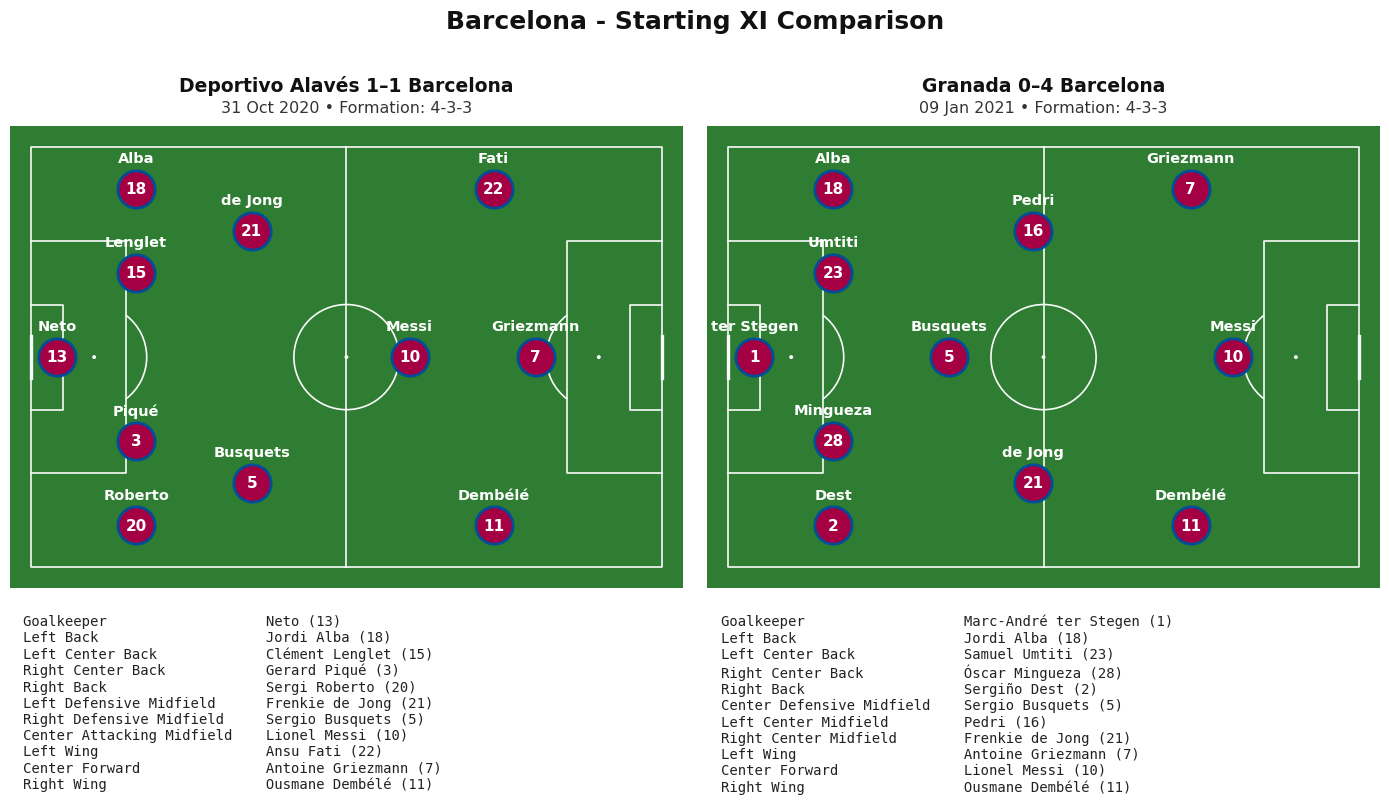

In [135]:
plot_formation_comparison(
    match_id_1=3773386,
    match_id_2=3773565,
    team="Barcelona"
)

In [136]:
# --- Filter El Clásico matches ---
clasicos = matches[
    (
        ((matches["home_team"] == "Barcelona") & (matches["away_team"] == "Real Madrid")) |
        ((matches["home_team"] == "Real Madrid") & (matches["away_team"] == "Barcelona"))
    )
].sort_values("match_date").reset_index(drop=True)


# --- Compute formations ---
clasicos["home_formation"] = clasicos.apply(
    lambda row: infer_formation(get_starting_xi(row["match_id"], row["home_team"])),
    axis=1
)

clasicos["away_formation"] = clasicos.apply(
    lambda row: infer_formation(get_starting_xi(row["match_id"], row["away_team"])),
    axis=1
)


# --- Final table ---
clasicos_table = clasicos[[
    "match_id",
    "match_date",
    "home_team",
    "away_team",
    "home_score",
    "away_score",
    "home_formation",
    "away_formation"
]]

clasicos_table

,match_id,match_date,home_team,away_team,home_score,away_score,home_formation,away_formation
0,3888713,1974-02-17,Real Madrid,Barcelona,0,5,3-3-3,4-3-3
1,68319,2005-11-19,Real Madrid,Barcelona,0,3,4-3-3,4-3-3
2,68330,2006-10-22,Real Madrid,Barcelona,2,0,4-3-3,4-3-3
3,68335,2007-03-10,Barcelona,Real Madrid,3,3,3-4-3,4-3-3
4,68361,2008-05-07,Real Madrid,Barcelona,4,1,4-3-3,4-3-3
5,69225,2008-12-13,Barcelona,Real Madrid,2,0,4-3-3,4-4-2
6,69249,2009-05-02,Real Madrid,Barcelona,2,6,4-4-2,4-3-3
7,69262,2009-11-29,Barcelona,Real Madrid,1,0,4-3-3,4-3-3
8,69259,2010-04-10,Real Madrid,Barcelona,0,2,4-4-2,4-3-3
9,69299,2010-11-29,Barcelona,Real Madrid,5,0,4-3-3,4-3-3


⚠️ Unmapped positions: ['Left Center Forward' 'Left Midfield' 'Right Midfield'
 'Right Center Forward']


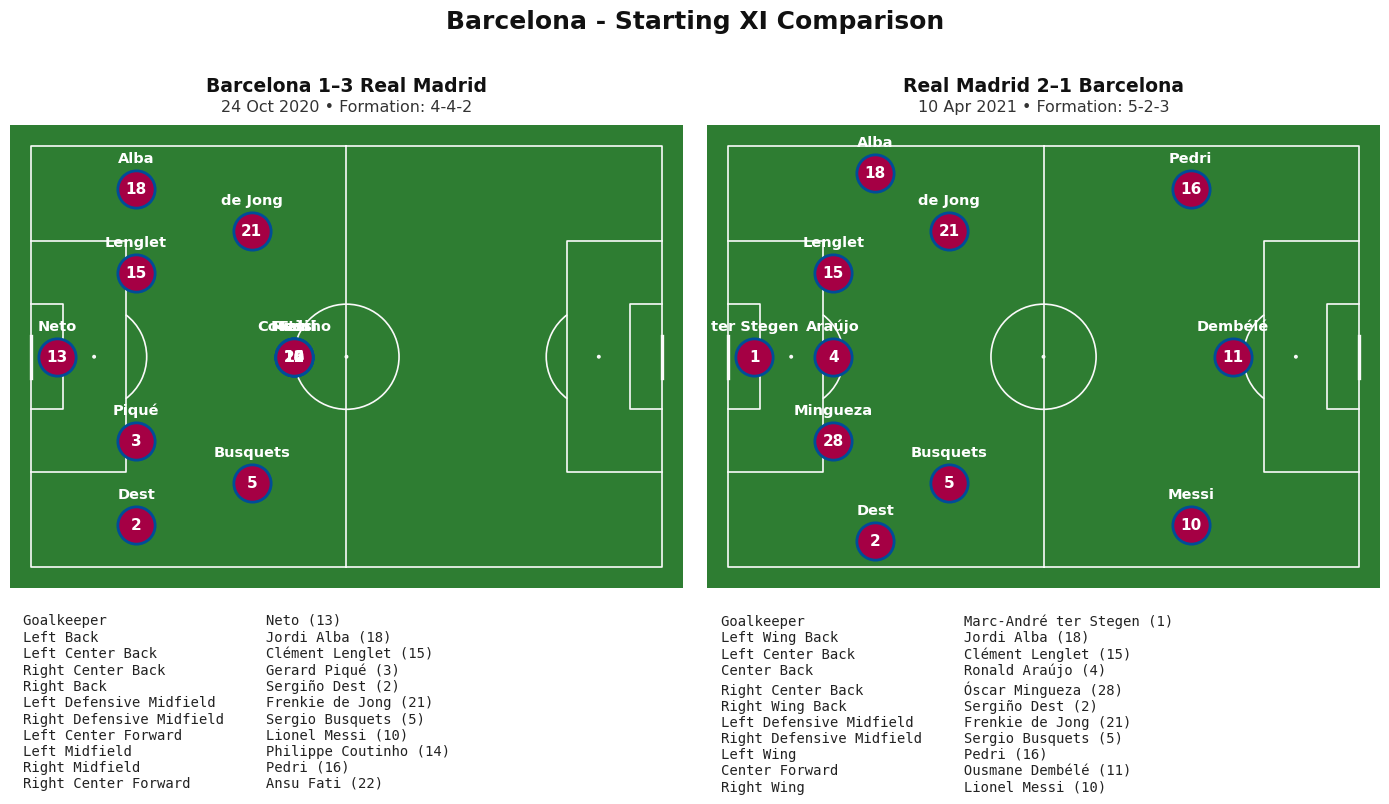

In [137]:
plot_formation_comparison(
    match_id_1=3773585,
    match_id_2=3773497,
    team="Barcelona"
)

In [133]:
barca_matches = matches[
    (matches["home_team"] == "Barcelona") |
    (matches["away_team"] == "Barcelona")
]

formations = []

for m_id in barca_matches["match_id"].head(20):  # limit for speed
    try:
        xi = get_starting_xi(m_id, "Barcelona")
        formation = infer_formation(xi)

        formations.append(formation)
    except:
        continue

pd.Series(formations).value_counts()

4-3-3    10
5-3-2     6
5-2-3     1
4-4-2     1
4-5-1     1
5-4-1     1
Name: count, dtype: int64